### **ABLATION STUDY ON MAMBA (barebones) LANGUAGE MODEL**

**IMPORTS**

In [1]:
import torch
import os, sys, time, copy, pickle as pkl
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
from model.mamba_layer import selective_scan
torch.manual_seed(0)

B = 2
D = 16
L = 64      # power of 2
N = 8

x  = torch.randn(B, D, L)
dt = torch.rand(B, D, L)
A  = -torch.rand(D, N)
Bm = torch.randn(B, N, L)
C  = torch.randn(B, N, L)
Dm = torch.randn(D)

y_seq = selective_scan(
    x, dt, A, Bm, C, D=Dm,
    parallel=False
)

y_par = selective_scan(
    x, dt, A, Bm, C, D=Dm,
    parallel=True
)

print("max abs error =", (y_seq - y_par).abs().max())
print("mean abs error =", (y_seq - y_par).abs().mean())

tensor(0.3744) tensor(1.0000)
tensor(0.3744) tensor(1.0000)
max abs error = tensor(4.2915e-06)
mean abs error = tensor(3.1889e-07)


In [3]:
y_seq, h_seq = selective_scan(
    x, dt, A, Bm, C,
    return_last_state=True,
    parallel=False
)

y_par, h_par = selective_scan(
    x, dt, A, Bm, C,
    return_last_state=True,
    parallel=True
)

print("output error =", (y_seq - y_par).abs().max())
print("state error  =", (h_seq - h_par).abs().max())

tensor(0.3744) tensor(1.0000)
tensor(0.3744) tensor(1.0000)
output error = tensor(4.2915e-06)
state error  = tensor(1.7881e-06)


In [4]:
x = torch.randn(B, D, L, requires_grad=True)
dt = torch.rand(B, D, L, requires_grad=True)

y_seq = selective_scan(
    x, dt, A, Bm, C,
    parallel=False
)

loss_seq = y_seq.sum()
loss_seq.backward()

grad_x_seq = x.grad.clone()
grad_dt_seq = dt.grad.clone()

x.grad.zero_()
dt.grad.zero_()

y_par = selective_scan(
    x, dt, A, Bm, C,
    parallel=True
)

loss_par = y_par.sum()
loss_par.backward()

print(
    "grad x error =",
    (grad_x_seq - x.grad).abs().max()
)

print(
    "grad dt error =",
    (grad_dt_seq - dt.grad).abs().max()
)

tensor(0.3756, grad_fn=<MinBackward1>) tensor(1.0000, grad_fn=<MaxBackward1>)
tensor(0.3756, grad_fn=<MinBackward1>) tensor(1.0000, grad_fn=<MaxBackward1>)
grad x error = tensor(22.9268)
grad dt error = tensor(56.7549)


In [2]:
from model.parallel_scan import pscan
torch.manual_seed(0)

B,L,D,N = 2,16,4,3

A = torch.rand(B,L,D,N, requires_grad=True)
X = torch.rand(B,L,D,N, requires_grad=True)

H = pscan(A, X)
loss = H.sum()
loss.backward()

gradA_pscan = A.grad.clone()
gradX_pscan = X.grad.clone()
A2 = A.detach().clone().requires_grad_(True)
X2 = X.detach().clone().requires_grad_(True)

state = torch.zeros(B,D,N)

outputs = []

for t in range(L):
    state = A2[:,t] * state + X2[:,t]
    outputs.append(state)

H2 = torch.stack(outputs, dim=1)

loss2 = H2.sum()
loss2.backward()
print((H-H2).abs().max())

print((A.grad - A2.grad).abs().max())
print((X.grad - X2.grad).abs().max())

tensor(2.3842e-07, grad_fn=<MaxBackward1>)
tensor(4.7684e-07)
tensor(4.7684e-07)


In [3]:
print("A grad max:", (A.grad - A2.grad).abs().max())
print("A grad mean:", (A.grad - A2.grad).abs().mean())

print("X grad max:", (X.grad - X2.grad).abs().max())
print("X grad mean:", (X.grad - X2.grad).abs().mean())

A grad max: tensor(4.7684e-07)
A grad mean: tensor(5.5452e-08)
X grad max: tensor(4.7684e-07)
X grad mean: tensor(3.9426e-08)


In [ ]:
from itertools import product
from copy import deepcopy

weight_decays = [0.0, 0.01, 0.05, 0.1]
dropouts = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
architectures = [
    {"d_model": 64, "n_layer": 2 ,"d_state":16},
    {"d_model": 64, "n_layer": 4 ,"d_state":16},
    {"d_model": 64, "n_layer": 6 ,"d_state":16},
    {"d_model": 128, "n_layer": 2 ,"d_state":16},
    {"d_model": 128, "n_layer": 4,"d_state":16},
    {"d_model": 128, "n_layer": 6,"d_state":16},
    {"d_model": 256, "n_layer": 2,"d_state":16},
    {"d_model": 256, "n_layer": 4,"d_state":16},
    {"d_model": 256, "n_layer": 6,"d_state":16},
    {"d_model": 64, "n_layer": 2 ,"d_state":32},
    {"d_model": 64, "n_layer": 4 ,"d_state":32},
    {"d_model": 64, "n_layer": 6 ,"d_state":32},
    {"d_model": 128, "n_layer": 2 ,"d_state":32},
    {"d_model": 128, "n_layer": 4,"d_state":32},
    {"d_model": 128, "n_layer": 6,"d_state":32},
    {"d_model": 256, "n_layer": 2,"d_state":32},
    {"d_model": 256, "n_layer": 4,"d_state":32},
    {"d_model": 256, "n_layer": 6,"d_state":32},
]

schedulers = ["constant","cosine","step",]
experiment_id = 0
results = []

for wd, dropout, arch, scheduler in product(weight_decays,dropouts,architectures,schedulers,):

    experiment_id += 1

    print("=" * 80)
    print(f"Experiment {experiment_id}")
    print(
        f"wd={wd}, "
        f"dropout={dropout}, "
        f"d_model={arch['d_model']}, "
        f"n_layer={arch['n_layer']}, "
        f"scheduler={scheduler}"
    )
    print("=" * 80)

    cfg = deepcopy(base_config)

    # architecture
    cfg.d_model = arch["d_model"]
    cfg.n_layer = arch["n_layer"]

    # dropout
    cfg.dropout = dropout

    # optimizer
    cfg.weight_decay = wd

    # scheduler
    cfg.scheduler = scheduler

    model = MambaLM(cfg).to(device)

    trained_model = train_model(
        model=model,
        train_data=train_data,
        valid_data=valid_data,
        args=cfg,
    )

    val_metrics = evaluate_model(
        trained_model,
        valid_data,
        cfg.batch_size,
    )

    results.append(
        {
            "experiment": experiment_id,
            "weight_decay": wd,
            "dropout": dropout,
            "d_model": arch["d_model"],
            "n_layer": arch["n_layer"],
            "scheduler": scheduler,
            "val_loss": val_metrics["loss"],
            "val_ppl": val_metrics["ppl"],
        }
    )

# -----------------------------
# Results table
# -----------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "val_ppl",
    ascending=True,
)

display(results_df)

results_df.to_csv(
    "hyperparameter_search_results.csv",
    index=False,
)

print("\nTop 10 experiments:")
display(results_df.head(10))

Experiment 1
wd=0.0, dropout=0.0, d_model=64, n_layer=2, scheduler=constant


NameError: name 'base_config' is not defined

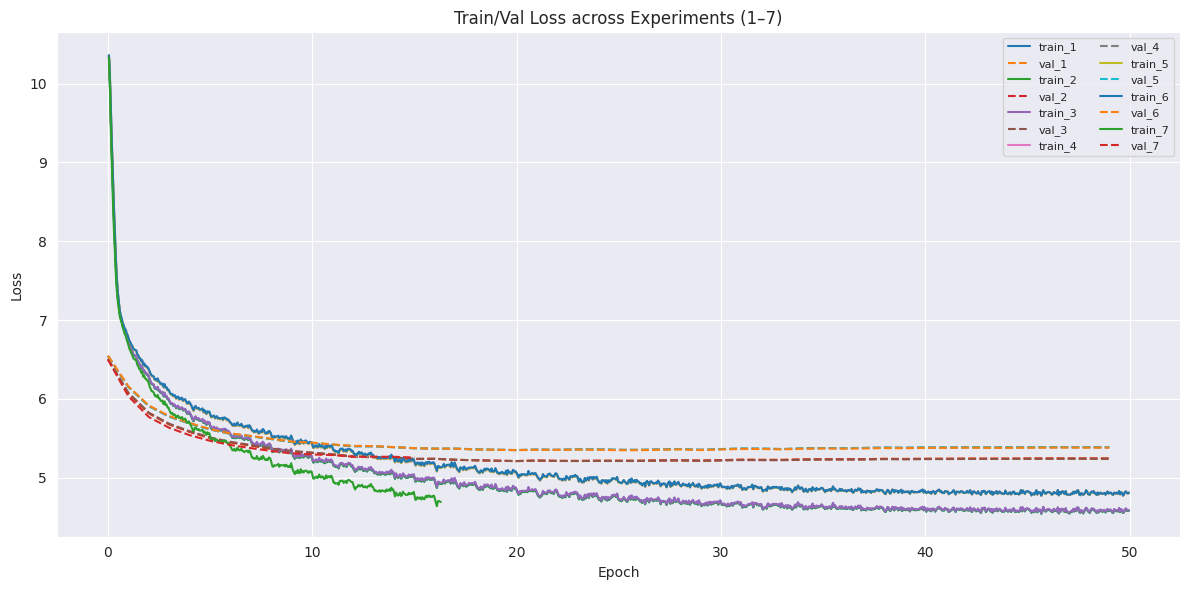

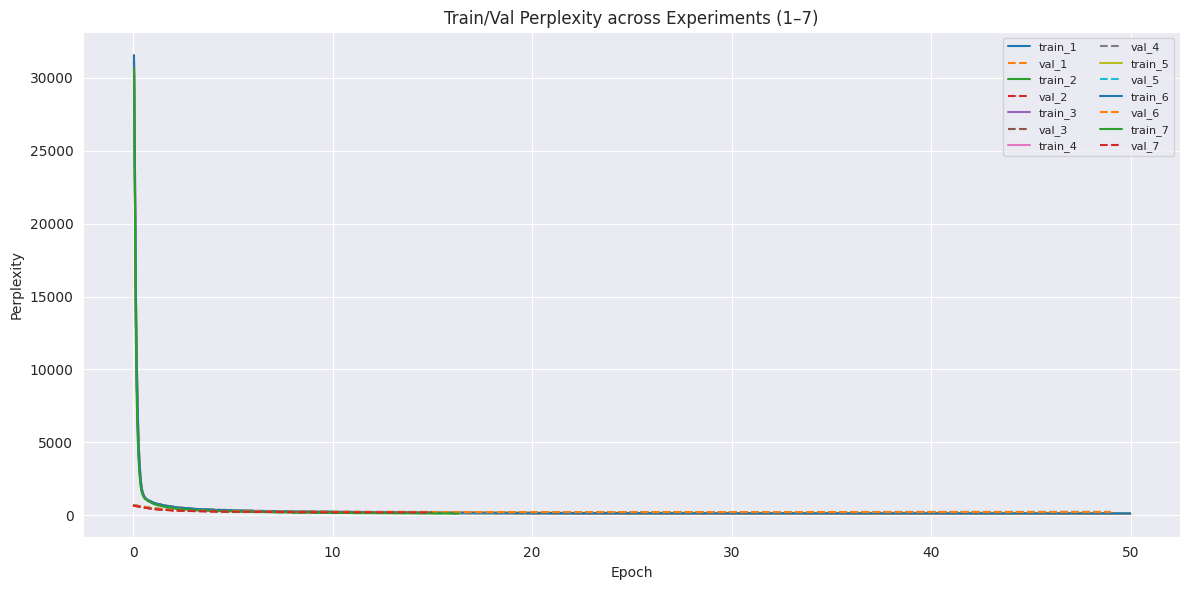

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

train_data = {}
val_data = {}

# Load data
for i in range(1, 8):
    train_path = f"logs/exp_00{i}.log_train.csv"
    val_path   = f"logs/exp_00{i}.log_val.csv"
    
    train_data[i] = pd.read_csv(train_path)
    val_data[i] = pd.read_csv(val_path)

# -------- LOSS PLOT --------
plt.figure(figsize=(12, 6))

for i in range(1, 8):
    plt.plot(train_data[i]["epoch"], train_data[i]["loss"], label=f"train_{i}")
    plt.plot(val_data[i]["epoch"], val_data[i]["loss"], linestyle="--", label=f"val_{i}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Val Loss across Experiments (1–7)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# -------- PERPLEXITY PLOT --------
plt.figure(figsize=(12, 6))

for i in range(1, 8):
    plt.plot(train_data[i]["epoch"], train_data[i]["ppl"], label=f"train_{i}")
    plt.plot(val_data[i]["epoch"], val_data[i]["ppl"], linestyle="--", label=f"val_{i}")

plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Train/Val Perplexity across Experiments (1–7)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

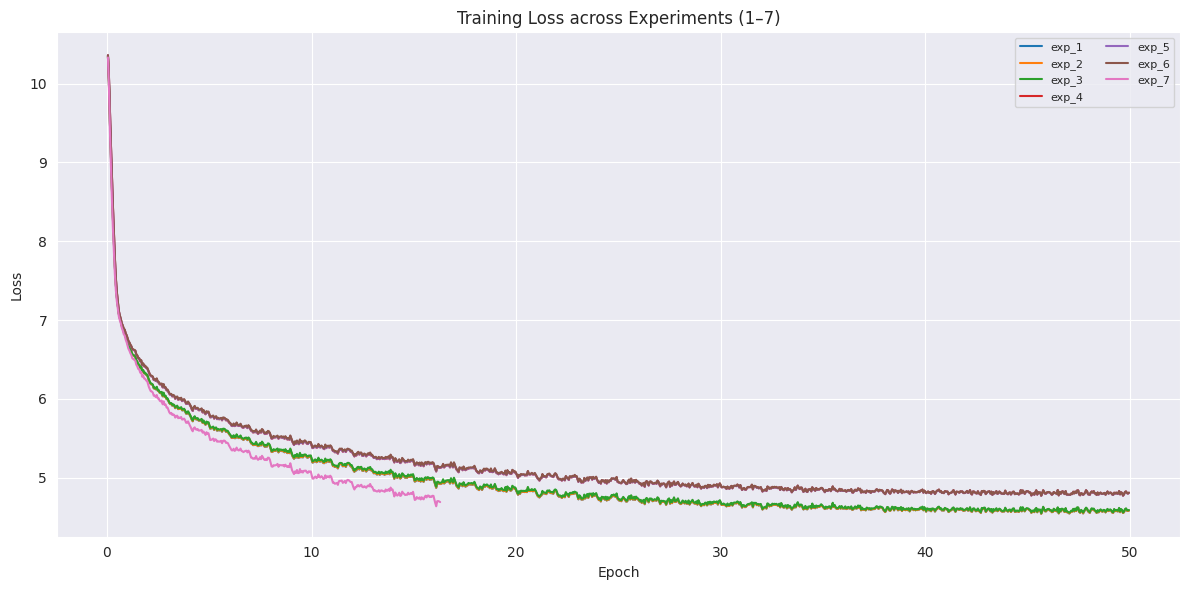

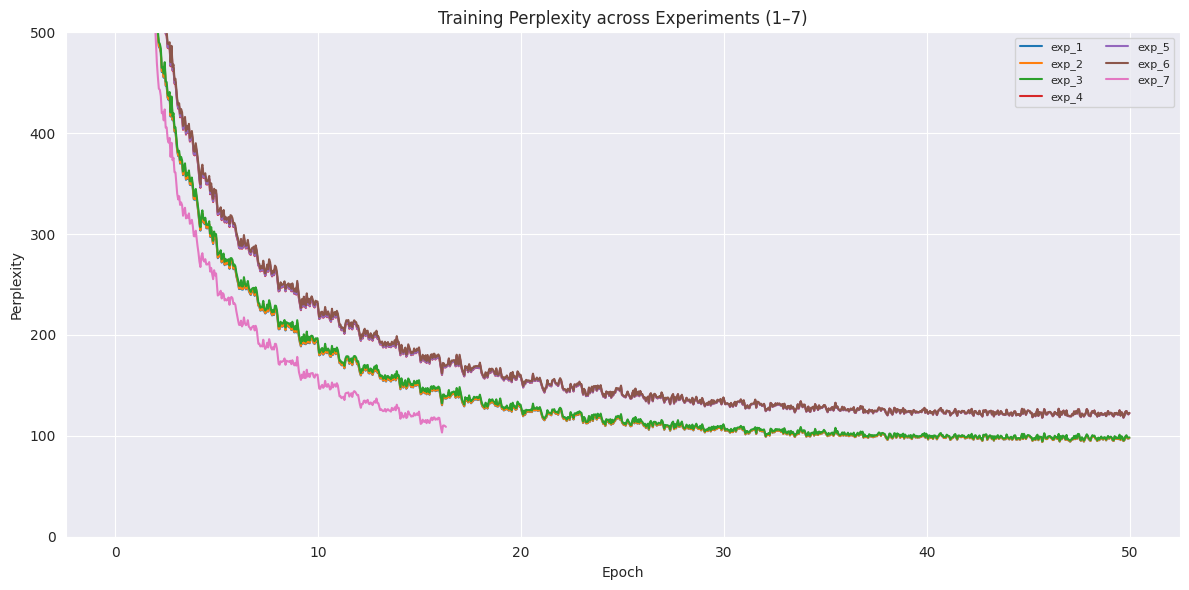

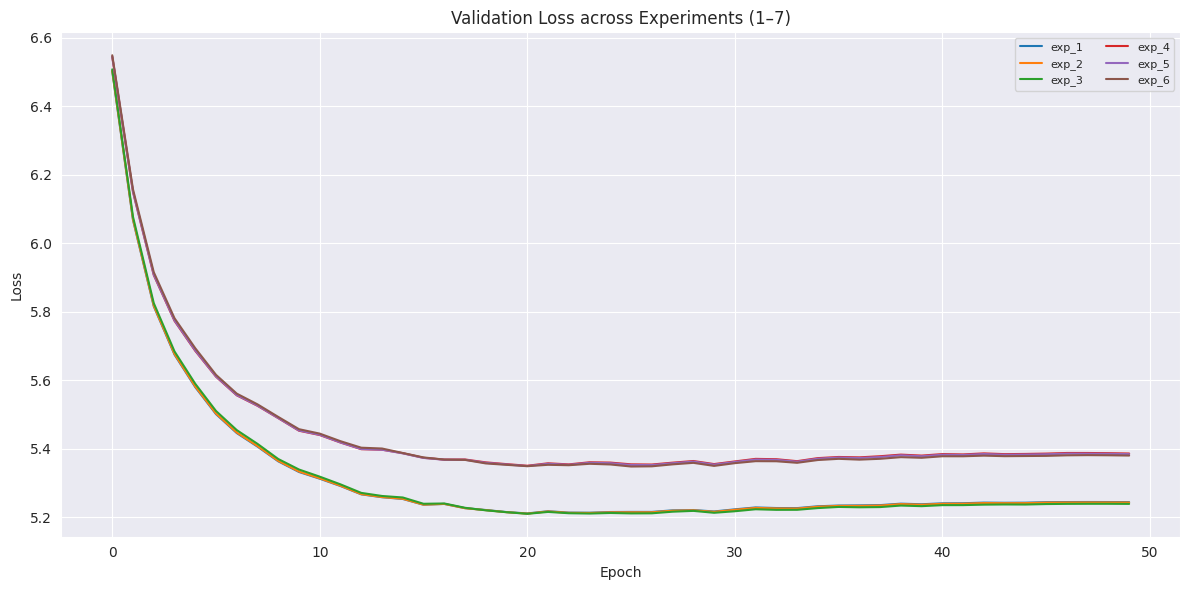

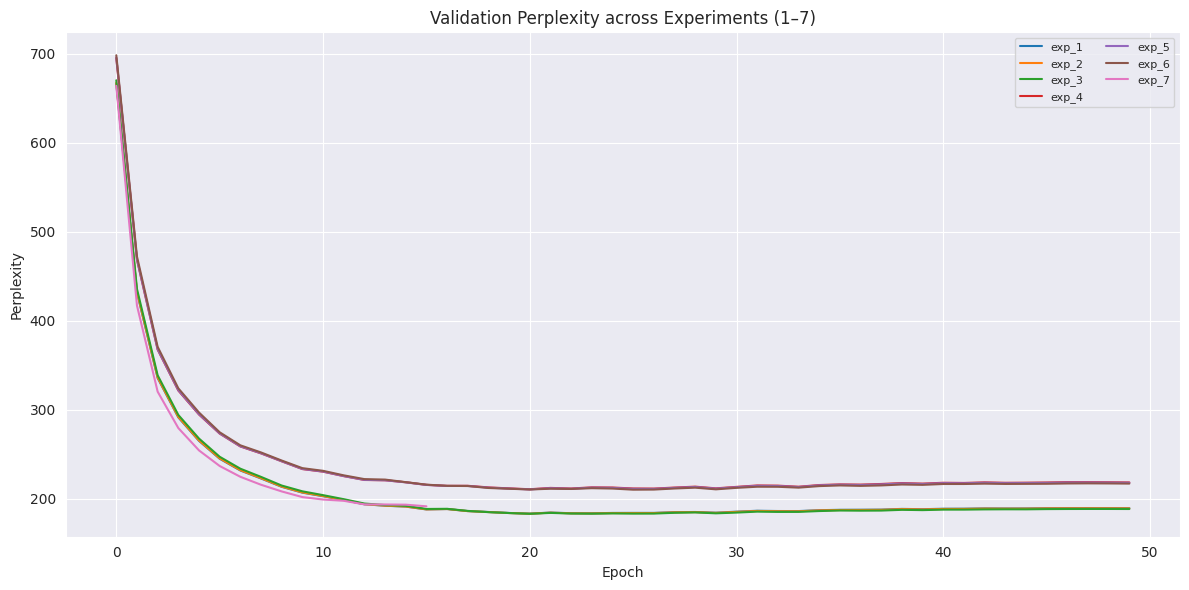

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

train_data = {}
val_data = {}

# Load data
for i in range(1, 8):
    train_path = f"logs/exp_00{i}.log_train.csv"
    val_path   = f"logs/exp_00{i}.log_val.csv"
    
    train_data[i] = pd.read_csv(train_path)
    val_data[i] = pd.read_csv(val_path)

# ---------------- TRAINING PLOTS ----------------
plt.figure(figsize=(12, 6))

for i in range(1, 7):
    plt.plot(train_data[i]["epoch"], train_data[i]["loss"], label=f"exp_{i}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for i in range(1, 7):
    plt.plot(train_data[i]["epoch"], train_data[i]["ppl"], label=f"exp_{i}")

plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.ylim(0,500)
plt.title("Training Perplexity")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------------- VALIDATION PLOTS ----------------
plt.figure(figsize=(12, 6))

for i in range(1, 7):
    plt.plot(val_data[i]["epoch"], val_data[i]["loss"], label=f"exp_{i}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

for i in range(1, 7):
    plt.plot(val_data[i]["epoch"], val_data[i]["ppl"], label=f"exp_{i}")

plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

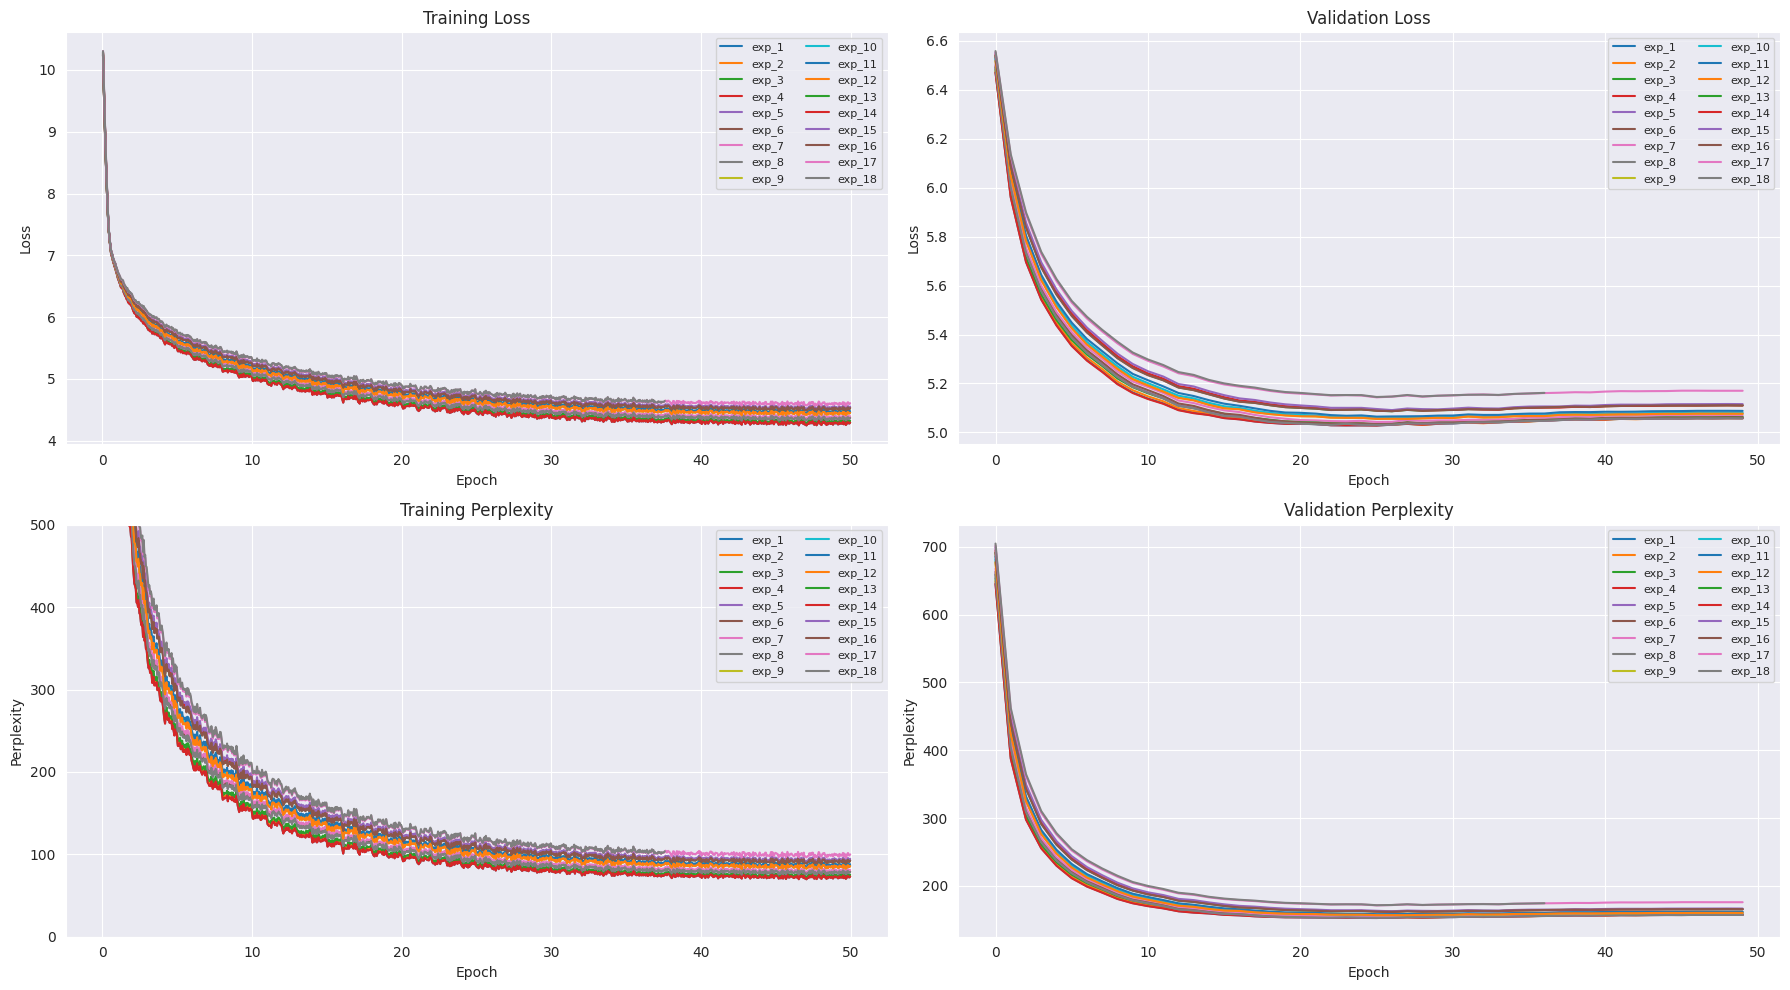

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

train_data = {}
val_data = {}

# Load data
for i in range(1, 19):
    if i<10:
        train_path = f"logs/exp_000{i}.log_train.csv"
        val_path   = f"logs/exp_000{i}.log_val.csv"
    else:
        train_path = f"logs/exp_00{i}.log_train.csv"
        val_path   = f"logs/exp_00{i}.log_val.csv"
    
    train_data[i] = pd.read_csv(train_path)
    val_data[i] = pd.read_csv(val_path)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ---------------- TRAIN LOSS ----------------
for i in range(1, 19):
    axes[0, 0].plot(train_data[i]["epoch"], train_data[i]["loss"], label=f"exp_{i}")

axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True)

# ---------------- VAL LOSS ----------------
for i in range(1, 19):
    axes[0, 1].plot(val_data[i]["epoch"], val_data[i]["loss"], label=f"exp_{i}")

axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True)

# ---------------- TRAIN PPL ----------------
for i in range(1, 19):
    axes[1, 0].plot(train_data[i]["epoch"], train_data[i]["ppl"], label=f"exp_{i}")

axes[1, 0].set_title("Training Perplexity")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Perplexity")
axes[1, 0].set_ylim(0, 500)
axes[1, 0].grid(True)

# ---------------- VAL PPL ----------------
for i in range(1, 19):
    axes[1, 1].plot(val_data[i]["epoch"], val_data[i]["ppl"], label=f"exp_{i}")

axes[1, 1].set_title("Validation Perplexity")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Perplexity")
axes[1, 1].grid(True)

# Add legends (once per subplot)
for ax in axes.flat:
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()